# Neuronpedia Attribution Graph Collection: 250+ Graphs across 8 Capability Domains

This notebook demonstrates the **Neuronpedia Attribution Graph Collection** dataset, which contains attribution graphs collected from the Neuronpedia API for the `gemma-2-2b` model.

**What this dataset contains:**
- Attribution graphs across **8 capability domains**: country_capital, arithmetic, antonym, translation, code_completion, multi_hop_reasoning, rhyme, sentiment
- Each record includes the full graph (nodes and edges), graph statistics (density, DAG validation), and domain labels
- Graphs contain 869–1875 nodes and 29K–107K edges in the full dataset

**What this notebook does:**
1. Loads a curated mini subset (3 trimmed graphs from different domains)
2. Parses graph structure (nodes, edges, feature types)
3. Computes and displays summary statistics per domain
4. Visualizes graph properties and structure

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# networkx, matplotlib, numpy — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'networkx==3.4.2', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import copy
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from tabulate import tabulate

## Load Data

Load the mini demo dataset from GitHub (with local fallback).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/dataset_iter1_neuronpedia_att/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded dataset: {data['datasets'][0]['dataset']}")
print(f"Number of examples: {len(data['datasets'][0]['examples'])}")
print(f"Model: {data['metadata']['model']}")
print(f"Source: {data['metadata']['source']}")

Loaded dataset: neuronpedia_attribution_graphs
Number of examples: 3
Model: gemma-2-2b
Source: Neuronpedia API (POST /api/graph/generate)


## Configuration

Tunable parameters for the demo analysis.

In [5]:
# --- Config ---
# Number of examples to process (set to all available in mini dataset)
N_EXAMPLES = 3  # full dataset has 250+, mini has 3

# Maximum string length for preview truncation
STRING_TRUNCATE_LEN = 200

# Visualization settings
MAX_VIS_NODES = 60  # max nodes to display in graph visualization
VIS_FIGSIZE = (16, 5)  # figure size for plots
GRAPH_LAYOUT_SEED = 42  # seed for reproducible graph layouts

# Dataset metadata
DATASET_NAME = "neuronpedia_attribution_graphs"

## Parse and Convert Records

Extract graph structure from each example. Each record's `output` field is a JSON-encoded string containing the full attribution graph (nodes, links, and statistics).

In [6]:
def convert_record(record, idx):
    """Convert a dataset example: parse the JSON-encoded graph output."""
    prompt = record["input"]
    output_data = json.loads(record["output"])

    # Collect feature types present in nodes
    feature_types = set()
    for node in output_data.get("nodes", []):
        ft = node.get("feature_type", "")
        if ft:
            feature_types.add(ft)

    example = {
        "input": prompt,
        "output_data": output_data,  # parsed graph dict
        "metadata_fold": record["metadata_fold"],
        "metadata_n_nodes": record["metadata_n_nodes"],
        "metadata_n_edges": record["metadata_n_edges"],
        "metadata_density": record["metadata_density"],
        "metadata_is_dag": record["metadata_is_dag"],
        "metadata_slug": record.get("metadata_slug", ""),
        "metadata_task_type": record.get("metadata_task_type", "graph_generation"),
        "metadata_n_classes": record.get("metadata_n_classes", 8),
        "metadata_row_index": idx,
        "metadata_feature_names": sorted(feature_types),
    }
    return example

# Convert all examples
examples_raw = data["datasets"][0]["examples"][:N_EXAMPLES]
examples = []
for idx, record in enumerate(examples_raw):
    example = convert_record(record, idx)
    examples.append(example)

print(f"Converted {len(examples)} examples")
for ex in examples:
    print(f"  [{ex['metadata_fold']}] \"{ex['input']}\" — "
          f"nodes={ex['metadata_n_nodes']}, edges={ex['metadata_n_edges']}, "
          f"density={ex['metadata_density']:.4f}, DAG={ex['metadata_is_dag']}")

Converted 3 examples
  [country_capital] "The capital of Japan is" — nodes=1048, edges=48109, density=0.0438, DAG=True
  [arithmetic] "3 + 5 =" — nodes=869, edges=31722, density=0.0421, DAG=True
  [antonym] "The opposite of happy is" — nodes=1088, edges=51677, density=0.0437, DAG=True


## Dataset Summary Statistics

Print a summary table showing graph statistics per capability domain, mirroring the original `data.py` output format.

In [7]:
def print_summary(examples):
    """Print summary statistics of the dataset (from original data.py)."""
    domains = Counter(ex["metadata_fold"] for ex in examples)
    
    print(f"{'='*70}")
    print(f"Dataset Summary: {len(examples)} attribution graphs across {len(domains)} domains")
    print(f"{'='*70}")
    
    rows = []
    for domain in sorted(domains.keys()):
        domain_examples = [ex for ex in examples if ex["metadata_fold"] == domain]
        n_nodes_list = [ex["metadata_n_nodes"] for ex in domain_examples]
        n_edges_list = [ex["metadata_n_edges"] for ex in domain_examples]
        dag_pct = sum(1 for ex in domain_examples if ex["metadata_is_dag"]) / len(domain_examples) * 100
        density_list = [ex["metadata_density"] for ex in domain_examples]
        rows.append([
            domain,
            len(domain_examples),
            f"{min(n_nodes_list)}-{max(n_nodes_list)}",
            f"{min(n_edges_list)}-{max(n_edges_list)}",
            f"{np.mean(density_list):.4f}",
            f"{dag_pct:.0f}%",
        ])
    
    print(tabulate(rows,
                   headers=["Domain", "Count", "Nodes (range)", "Edges (range)", "Avg Density", "DAG%"],
                   tablefmt="simple"))
    print(f"{'='*70}")

print_summary(examples)

Dataset Summary: 3 attribution graphs across 3 domains
Domain             Count  Nodes (range)    Edges (range)      Avg Density  DAG%
---------------  -------  ---------------  ---------------  -------------  ------
antonym                1  1088-1088        51677-51677             0.0437  100%
arithmetic             1  869-869          31722-31722             0.0421  100%
country_capital        1  1048-1048        48109-48109             0.0438  100%


## Domain Distribution & Feature Type Analysis

Analyze the distribution of examples across domains and the feature types present in graph nodes.

In [8]:
# Domain distribution
domains = Counter(ex["metadata_fold"] for ex in examples)
print(f"Domain distribution: {dict(sorted(domains.items()))}")

# Feature type analysis across all examples
all_feature_types = Counter()
for ex in examples:
    for ft in ex["metadata_feature_names"]:
        all_feature_types[ft] += 1

print(f"\nFeature types found across all graphs:")
for ft, count in all_feature_types.most_common():
    print(f"  {ft}: present in {count}/{len(examples)} graphs")

# Node-level feature type distribution per example
print(f"\nPer-graph node feature type counts:")
for ex in examples:
    ft_counts = Counter(n.get("feature_type", "unknown") for n in ex["output_data"]["nodes"])
    print(f"  [{ex['metadata_fold']}] \"{ex['input']}\":")
    for ft, c in ft_counts.most_common():
        print(f"    {ft}: {c} nodes")

Domain distribution: {'antonym': 1, 'arithmetic': 1, 'country_capital': 1}

Feature types found across all graphs:
  cross layer transcoder: present in 3/3 graphs
  embedding: present in 3/3 graphs

Per-graph node feature type counts:
  [country_capital] "The capital of Japan is":
    cross layer transcoder: 57 nodes
    embedding: 3 nodes
  [arithmetic] "3 + 5 =":
    cross layer transcoder: 57 nodes
    embedding: 3 nodes
  [antonym] "The opposite of happy is":
    cross layer transcoder: 57 nodes
    embedding: 3 nodes


## Schema Wrapping & Preview Generation

Demonstrate the schema wrapping and string truncation utilities from the original `data.py` pipeline.

In [9]:
METADATA_BLOCK = {
    "source": "Neuronpedia API (POST /api/graph/generate)",
    "model": "gemma-2-2b",
    "description": "Attribution graphs across 8 capability domains",
    "collection_params": {
        "nodeThreshold": 0.8,
        "edgeThreshold": 0.85,
        "maxFeatureNodes": 5000,
        "maxNLogits": 10,
        "desiredLogitProb": 0.95,
    },
}

def wrap_schema(examples_list):
    """Wrap examples list in the exp_sel_data_out schema structure."""
    return {
        "metadata": METADATA_BLOCK,
        "datasets": [{"dataset": DATASET_NAME, "examples": examples_list}],
    }

def truncate_strings(obj, max_len=STRING_TRUNCATE_LEN):
    """Recursively truncate all strings in an object to max_len chars."""
    if isinstance(obj, str):
        return obj[:max_len] + "..." if len(obj) > max_len else obj
    elif isinstance(obj, dict):
        return {k: truncate_strings(v, max_len) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [truncate_strings(item, max_len) for item in obj]
    return obj

# Demo: create a preview of the first example
preview_ex = truncate_strings(data["datasets"][0]["examples"][0])
preview_wrapped = wrap_schema([preview_ex])
print("Preview (truncated strings) of first example:")
print(json.dumps(preview_wrapped, indent=2)[:1500])
print("...")

Preview (truncated strings) of first example:
{
  "metadata": {
    "source": "Neuronpedia API (POST /api/graph/generate)",
    "model": "gemma-2-2b",
    "description": "Attribution graphs across 8 capability domains",
    "collection_params": {
      "nodeThreshold": 0.8,
      "edgeThreshold": 0.85,
      "maxFeatureNodes": 5000,
      "maxNLogits": 10,
      "desiredLogitProb": 0.95
    }
  },
  "datasets": [
    {
      "dataset": "neuronpedia_attribution_graphs",
      "examples": [
        {
          "input": "The capital of Japan is",
          "output": "{\"nodes\":[{\"node_id\":\"0_7812_1\",\"feature\":30525390,\"layer\":\"0\",\"ctx_idx\":1,\"feature_type\":\"cross layer transcoder\",\"token_prob\":0.0,\"is_target_logit\":false,\"run_idx\":0,\"reverse_ctx_idx\":0,\"jsNodeId\":\"...",
          "metadata_fold": "country_capital",
          "metadata_n_nodes": 1048,
          "metadata_n_edges": 48109,
          "metadata_density": 0.043845,
          "metadata_is_dag": true,


## Visualization

### Graph Statistics Comparison

Compare node counts, edge counts, and density across the three example attribution graphs.

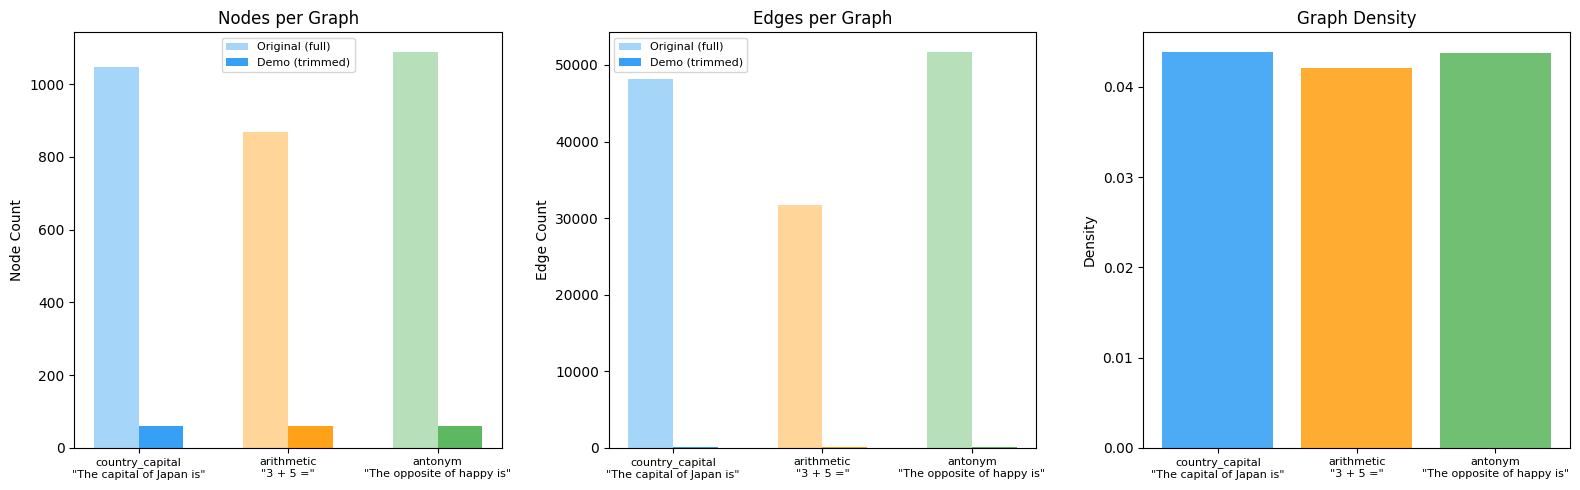

Saved: graph_statistics.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=VIS_FIGSIZE)

labels = [f"{ex['metadata_fold']}\n\"{ex['input']}\"" for ex in examples]
colors = ['#2196F3', '#FF9800', '#4CAF50']

# Plot 1: Node counts (original vs trimmed demo)
orig_nodes = [ex["metadata_n_nodes"] for ex in examples]
demo_nodes = [ex["output_data"]["n_nodes"] for ex in examples]
x = np.arange(len(labels))
axes[0].bar(x - 0.15, orig_nodes, 0.3, label="Original (full)", color=colors, alpha=0.4)
axes[0].bar(x + 0.15, demo_nodes, 0.3, label="Demo (trimmed)", color=colors, alpha=0.9)
axes[0].set_ylabel("Node Count")
axes[0].set_title("Nodes per Graph")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].legend(fontsize=8)

# Plot 2: Edge counts (original vs trimmed demo)
orig_edges = [ex["metadata_n_edges"] for ex in examples]
demo_edges = [ex["output_data"]["n_edges"] for ex in examples]
axes[1].bar(x - 0.15, orig_edges, 0.3, label="Original (full)", color=colors, alpha=0.4)
axes[1].bar(x + 0.15, demo_edges, 0.3, label="Demo (trimmed)", color=colors, alpha=0.9)
axes[1].set_ylabel("Edge Count")
axes[1].set_title("Edges per Graph")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].legend(fontsize=8)

# Plot 3: Density comparison
densities = [ex["metadata_density"] for ex in examples]
axes[2].bar(x, densities, color=colors, alpha=0.8)
axes[2].set_ylabel("Density")
axes[2].set_title("Graph Density")
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, fontsize=8)

plt.tight_layout()
plt.savefig("graph_statistics.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: graph_statistics.png")

### Attribution Graph Structure Visualization

Visualize the attribution graph topology for each domain using NetworkX. Nodes are colored by feature type, edge thickness reflects weight magnitude.

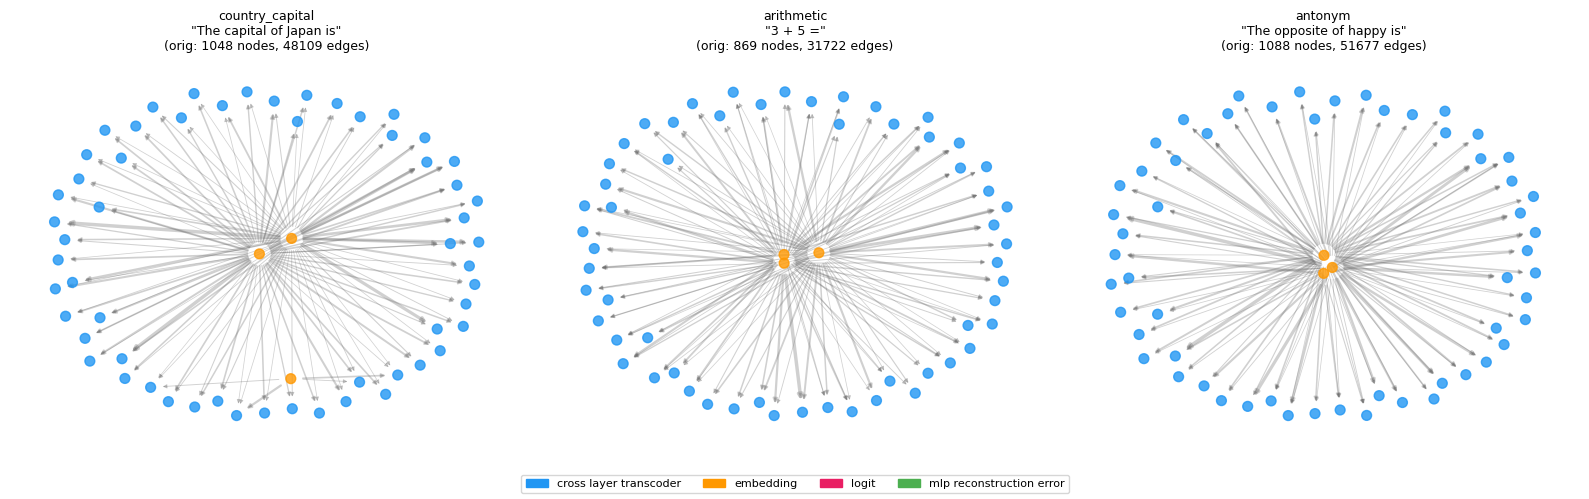

Saved: graph_structure.png


In [11]:
FEATURE_TYPE_COLORS = {
    "cross layer transcoder": "#2196F3",
    "embedding": "#FF9800",
    "logit": "#E91E63",
    "mlp reconstruction error": "#4CAF50",
}

fig, axes = plt.subplots(1, len(examples), figsize=VIS_FIGSIZE)
if len(examples) == 1:
    axes = [axes]

for ax_idx, ex in enumerate(examples):
    ax = axes[ax_idx]
    graph_data = ex["output_data"]
    nodes = graph_data["nodes"][:MAX_VIS_NODES]
    node_ids = {n["node_id"] for n in nodes}

    # Build NetworkX graph
    G = nx.DiGraph()
    for n in nodes:
        G.add_node(n["node_id"], feature_type=n.get("feature_type", "unknown"))

    for link in graph_data["links"]:
        if link["source"] in node_ids and link["target"] in node_ids:
            G.add_edge(link["source"], link["target"], weight=abs(link["weight"]))

    # Node colors by feature type
    node_colors = [FEATURE_TYPE_COLORS.get(G.nodes[n].get("feature_type", ""), "#999999") for n in G.nodes()]

    # Edge widths by weight
    if G.edges():
        weights = [G[u][v]["weight"] for u, v in G.edges()]
        max_w = max(weights) if weights else 1.0
        edge_widths = [0.5 + 2.0 * w / max_w for w in weights]
    else:
        edge_widths = []

    # Layout
    pos = nx.spring_layout(G, seed=GRAPH_LAYOUT_SEED, k=2.0 / max(1, len(G.nodes()) ** 0.5))

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=50, alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, alpha=0.3,
                           edge_color="#666666", arrows=True, arrowsize=6)

    ax.set_title(f"{ex['metadata_fold']}\n\"{ex['input']}\"\n"
                 f"(orig: {ex['metadata_n_nodes']} nodes, {ex['metadata_n_edges']} edges)",
                 fontsize=9)
    ax.axis("off")

# Legend
legend_patches = [mpatches.Patch(color=c, label=ft) for ft, c in FEATURE_TYPE_COLORS.items()]
fig.legend(handles=legend_patches, loc="lower center", ncol=len(FEATURE_TYPE_COLORS), fontsize=8)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("graph_structure.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: graph_structure.png")

### Edge Weight Distribution

Compare the distribution of edge weights across graphs from different capability domains.

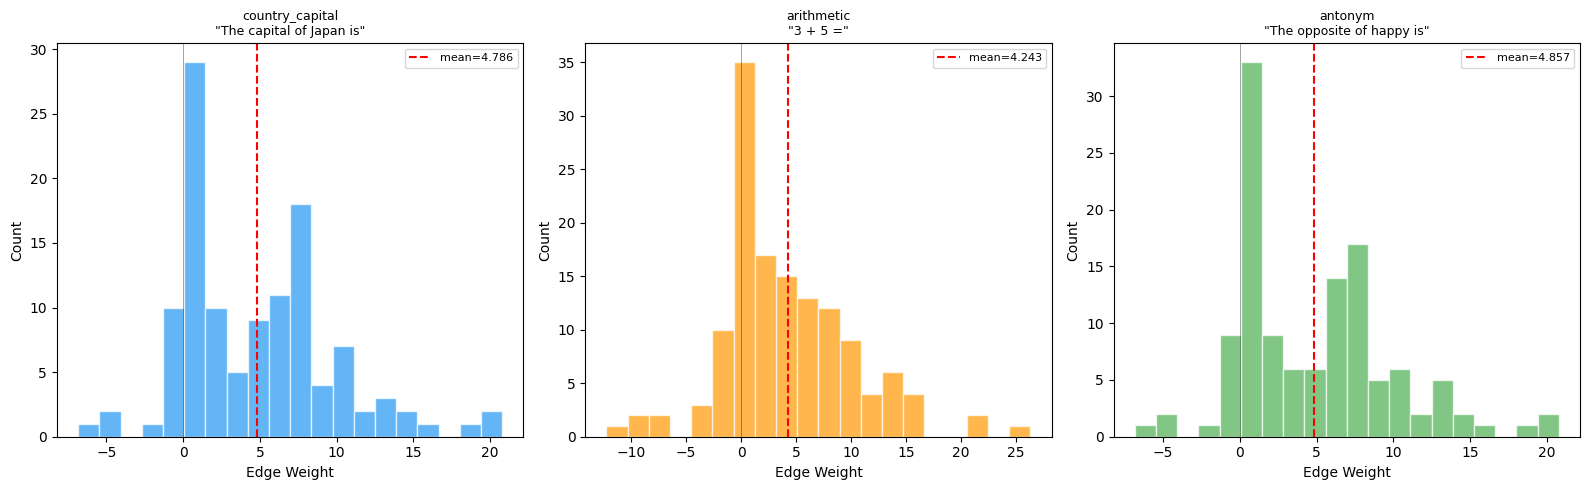

Saved: edge_weight_distribution.png

Demo complete!
Processed 3 attribution graphs from 3 domains
Full dataset contains 250+ graphs across 8 domains (country_capital, arithmetic,
antonym, translation, code_completion, multi_hop_reasoning, rhyme, sentiment)


In [12]:
fig, axes = plt.subplots(1, len(examples), figsize=VIS_FIGSIZE)
if len(examples) == 1:
    axes = [axes]
colors = ['#2196F3', '#FF9800', '#4CAF50']

for ax_idx, ex in enumerate(examples):
    ax = axes[ax_idx]
    weights = [link["weight"] for link in ex["output_data"]["links"]]
    if weights:
        ax.hist(weights, bins=20, color=colors[ax_idx], alpha=0.7, edgecolor="white")
        ax.axvline(np.mean(weights), color="red", linestyle="--", linewidth=1.5, label=f"mean={np.mean(weights):.3f}")
        ax.axvline(0, color="black", linestyle="-", linewidth=0.5, alpha=0.5)
        ax.legend(fontsize=8)
    ax.set_title(f"{ex['metadata_fold']}\n\"{ex['input']}\"", fontsize=9)
    ax.set_xlabel("Edge Weight")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("edge_weight_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: edge_weight_distribution.png")

# Final summary
print("\n" + "="*70)
print("Demo complete!")
print(f"Processed {len(examples)} attribution graphs from {len(set(ex['metadata_fold'] for ex in examples))} domains")
print(f"Full dataset contains 250+ graphs across 8 domains (country_capital, arithmetic,")
print(f"antonym, translation, code_completion, multi_hop_reasoning, rhyme, sentiment)")
print("="*70)